<a href="https://colab.research.google.com/github/Tanishqnarayan/AIML/blob/main/Aiml_8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Dataset loaded successfully!
Shape: (442, 11)

First 5 rows:


,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,151.0
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204,75.0
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,141.0
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362,206.0
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641,135.0



Features:
['age', 'sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6']

Target:
Disease progression measure

Training samples: 353
Testing samples: 89

Best Ridge Alpha: 1.0
Best Lasso Alpha: 0.5

================ MODEL COMPARISON ================


,Model,Train R2,Test R2,Test MAE,Test MSE,Test RMSE
0,Linear Regression,0.5279,0.4526,42.7941,2900.1936,53.8534
1,Ridge Regression,0.5276,0.4541,42.8120,2892.0146,53.7775
2,Lasso Regression,0.5245,0.4607,42.8395,2857.4990,53.4556



================ COEFFICIENT COMPARISON ================


,Feature,Linear Regression,Ridge Regression,Lasso Regression
0,age,1.7538,1.8073,1.3423
1,sex,-11.5118,-11.4482,-10.3907
2,bmi,25.6071,25.7327,26.2262
3,bp,16.8289,16.7343,16.1689
4,s1,-44.4489,-34.6720,-11.6644
5,s2,24.6410,17.0531,0.0000
6,s3,7.6770,3.3699,-6.4309
7,s4,13.1388,11.7643,7.4560
8,s5,35.1612,31.3784,23.0849
9,s6,2.3514,2.4581,2.3296



Number of coefficients reduced to zero by Lasso: 1


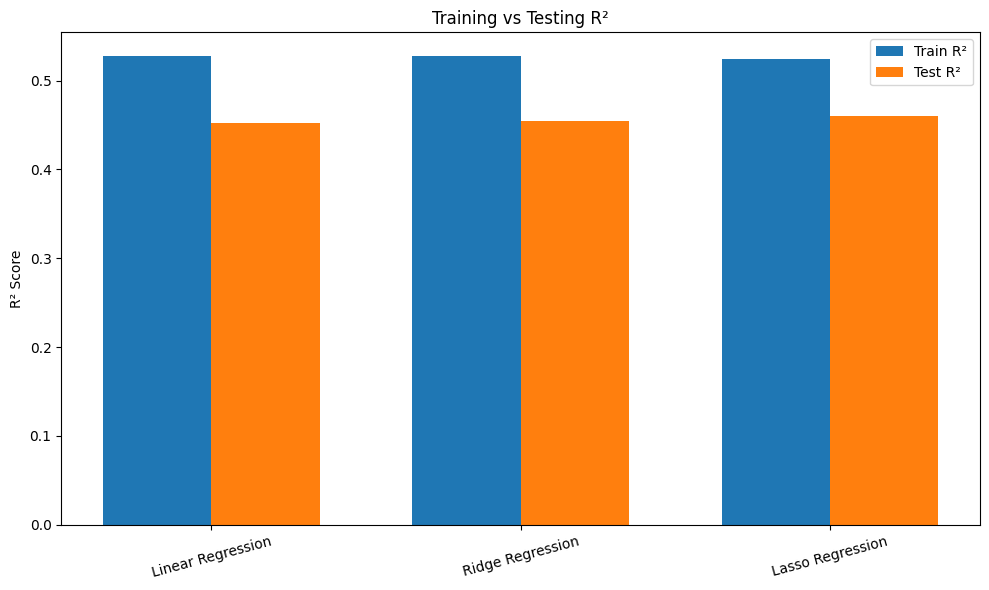

<Figure size 1200x700 with 0 Axes>

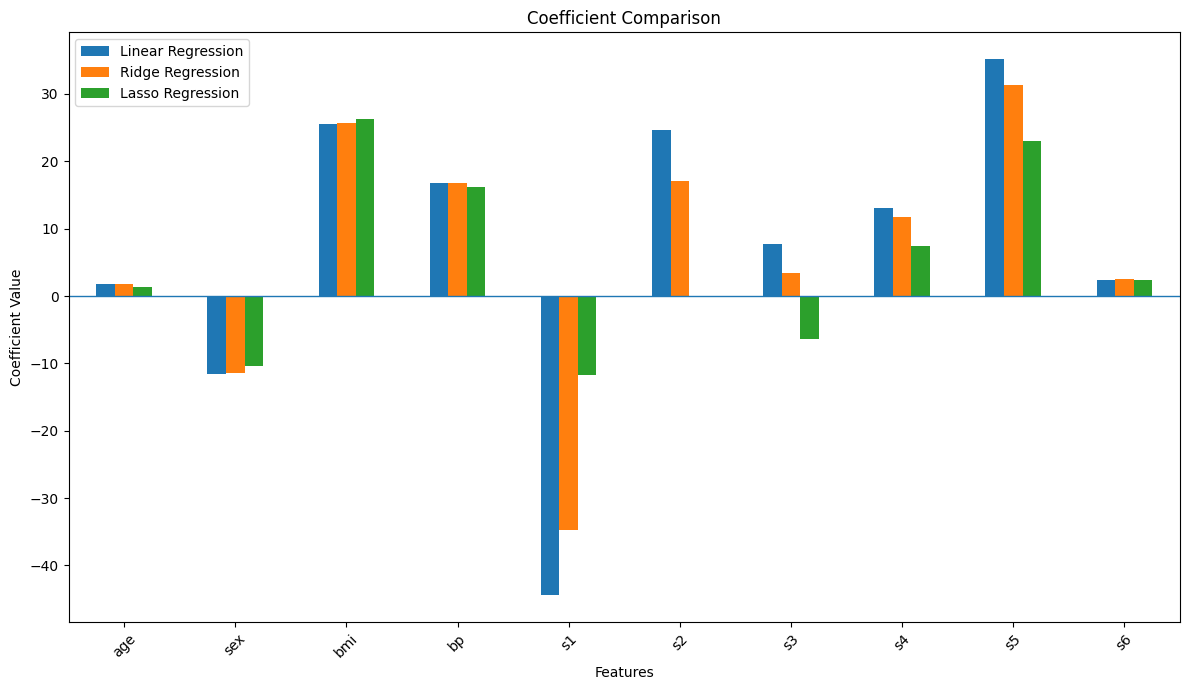

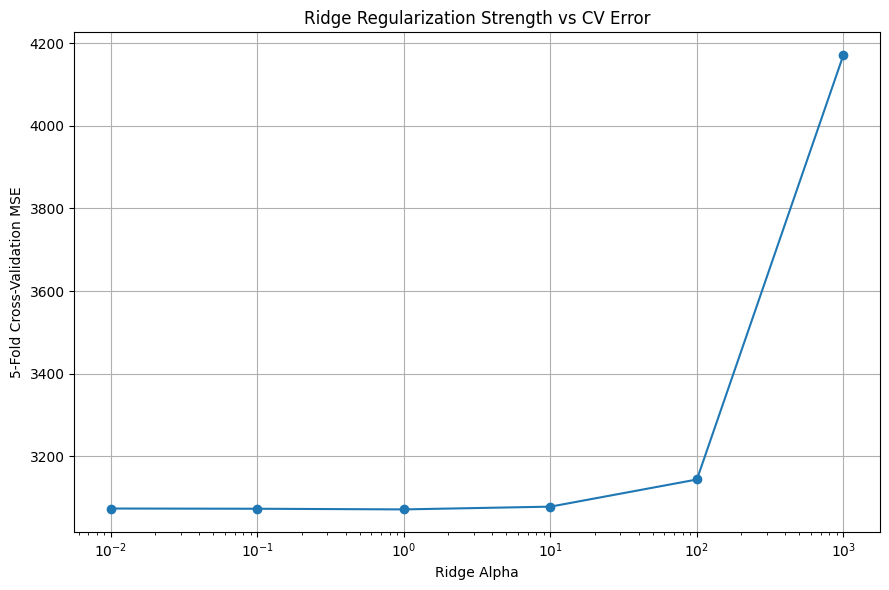

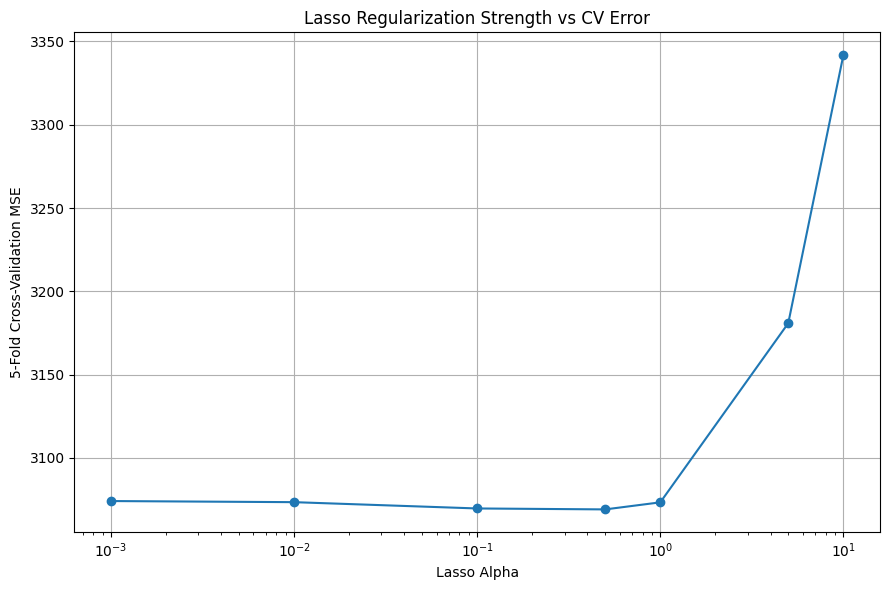

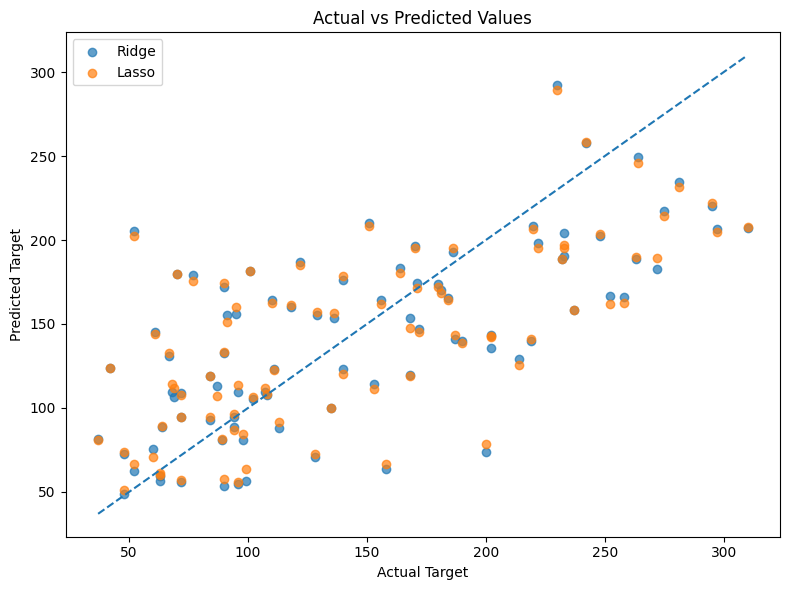

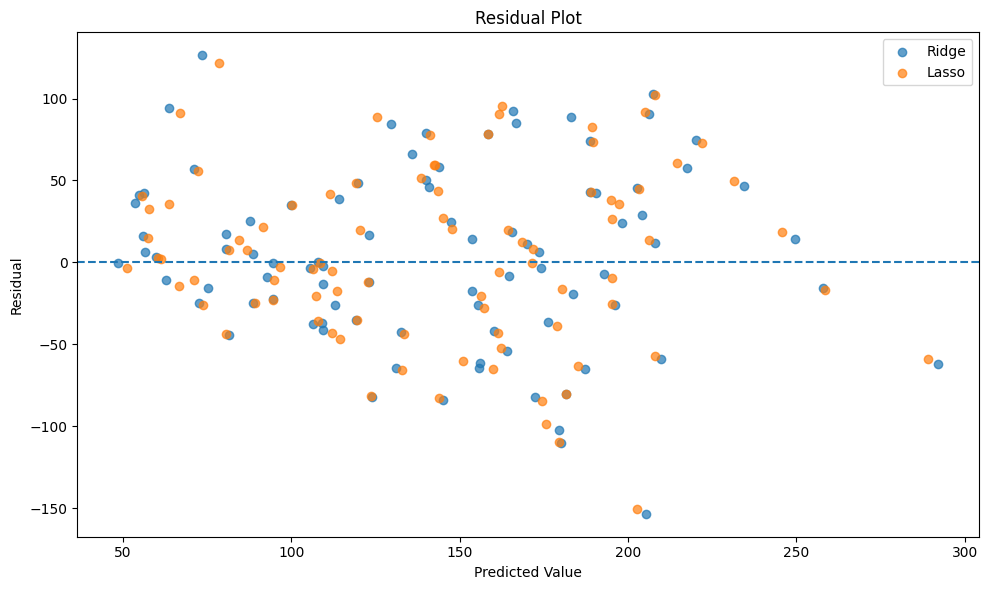


================ SAMPLE PREDICTIONS ================


,Actual,Linear_Predicted,Ridge_Predicted,Lasso_Predicted
0,219.0,139.548,139.863,141.239
1,70.0,179.517,179.958,179.503
2,202.0,134.039,135.717,142.435
3,230.0,291.417,292.116,289.050
4,111.0,123.790,123.189,122.645
5,84.0,92.172,92.634,94.706
6,242.0,258.232,257.855,258.529
7,272.0,181.337,182.984,189.410
8,94.0,90.224,88.571,86.684
9,96.0,108.634,109.341,113.612



AIML ASSIGNMENT 8
REGULARIZATION TO AVOID OVERFITTING

Dataset:
Scikit-learn Diabetes Dataset

Number of samples:
442

Number of independent features:
10

Models used:
1. Linear Regression
2. Ridge Regression
3. Lasso Regression

Best Ridge Alpha:
1.0

Best Lasso Alpha:
0.5

Linear Regression:
Train R2 = 0.5279
Test R2  = 0.4526
Test MAE = 42.7941
Test MSE = 2900.1936
Test RMSE = 53.8534

Ridge Regression:
Train R2 = 0.5276
Test R2  = 0.4541
Test MAE = 42.8120
Test MSE = 2892.0146
Test RMSE = 53.7775

Lasso Regression:
Train R2 = 0.5245
Test R2  = 0.4607
Test MAE = 42.8395
Test MSE = 2857.4990
Test RMSE = 53.4556

Main Observations:
1. Regularization adds a penalty to large model coefficients.
2. Ridge Regression uses L2 regularization.
3. Lasso Regression uses L1 regularization.
4. Ridge generally shrinks coefficients toward zero.
5. Lasso can reduce some coefficients exactly to zero.
6. Regularization can reduce model complexity and help control overfitting.
7. Alpha controls the st

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# ============================================================
# AIML ASSIGNMENT 8
# REGULARIZATION TO AVOID OVERFITTING
# Dataset: Scikit-learn Diabetes Dataset
# Models: Linear Regression, Ridge Regression, Lasso Regression
# ============================================================

# -----------------------------
# 1. IMPORT LIBRARIES
# -----------------------------
import os
import shutil
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


# -----------------------------
# 2. LOAD DATASET
# -----------------------------
data = load_diabetes(as_frame=True)
df = data.frame.copy()

print("Dataset loaded successfully!")
print("Shape:", df.shape)
print("\nFirst 5 rows:")
display(df.head())


# -----------------------------
# 3. DEFINE FEATURES AND TARGET
# -----------------------------
X = df.drop(columns=["target"])
y = df["target"]

print("\nFeatures:")
print(X.columns.tolist())

print("\nTarget:")
print("Disease progression measure")


# -----------------------------
# 4. TRAIN-TEST SPLIT
# -----------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("\nTraining samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])


# -----------------------------
# 5. STANDARDIZATION
# -----------------------------
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


# ============================================================
# 6. LINEAR REGRESSION
# ============================================================

linear_model = LinearRegression()
linear_model.fit(X_train_scaled, y_train)

linear_pred_train = linear_model.predict(X_train_scaled)
linear_pred_test = linear_model.predict(X_test_scaled)

linear_train_r2 = r2_score(y_train, linear_pred_train)
linear_test_r2 = r2_score(y_test, linear_pred_test)

linear_test_mae = mean_absolute_error(y_test, linear_pred_test)
linear_test_mse = mean_squared_error(y_test, linear_pred_test)
linear_test_rmse = np.sqrt(linear_test_mse)


# ============================================================
# 7. RIDGE REGRESSION
# ============================================================

ridge_alphas = [0.01, 0.1, 1, 10, 100, 1000]

ridge_cv_results = []

kf = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

for alpha in ridge_alphas:

    ridge_pipeline = Pipeline([
        ("scaler", StandardScaler()),
        ("ridge", Ridge(alpha=alpha))
    ])

    scores = cross_val_score(
        ridge_pipeline,
        X_train,
        y_train,
        cv=kf,
        scoring="neg_mean_squared_error"
    )

    mean_mse = -scores.mean()

    ridge_cv_results.append({
        "Alpha": alpha,
        "CV_MSE": mean_mse
    })

ridge_cv_df = pd.DataFrame(ridge_cv_results)

best_ridge_alpha = ridge_cv_df.loc[
    ridge_cv_df["CV_MSE"].idxmin(),
    "Alpha"
]

print("\nBest Ridge Alpha:", best_ridge_alpha)


# Train final Ridge model
ridge_model = Ridge(alpha=best_ridge_alpha)
ridge_model.fit(X_train_scaled, y_train)

ridge_pred_train = ridge_model.predict(X_train_scaled)
ridge_pred_test = ridge_model.predict(X_test_scaled)

ridge_train_r2 = r2_score(y_train, ridge_pred_train)
ridge_test_r2 = r2_score(y_test, ridge_pred_test)

ridge_test_mae = mean_absolute_error(y_test, ridge_pred_test)
ridge_test_mse = mean_squared_error(y_test, ridge_pred_test)
ridge_test_rmse = np.sqrt(ridge_test_mse)


# ============================================================
# 8. LASSO REGRESSION
# ============================================================

lasso_alphas = [0.001, 0.01, 0.1, 0.5, 1, 5, 10]

lasso_cv_results = []

for alpha in lasso_alphas:

    lasso_pipeline = Pipeline([
        ("scaler", StandardScaler()),
        ("lasso", Lasso(alpha=alpha, max_iter=100000))
    ])

    scores = cross_val_score(
        lasso_pipeline,
        X_train,
        y_train,
        cv=kf,
        scoring="neg_mean_squared_error"
    )

    mean_mse = -scores.mean()

    lasso_cv_results.append({
        "Alpha": alpha,
        "CV_MSE": mean_mse
    })

lasso_cv_df = pd.DataFrame(lasso_cv_results)

best_lasso_alpha = lasso_cv_df.loc[
    lasso_cv_df["CV_MSE"].idxmin(),
    "Alpha"
]

print("Best Lasso Alpha:", best_lasso_alpha)


# Train final Lasso model
lasso_model = Lasso(
    alpha=best_lasso_alpha,
    max_iter=100000
)

lasso_model.fit(X_train_scaled, y_train)

lasso_pred_train = lasso_model.predict(X_train_scaled)
lasso_pred_test = lasso_model.predict(X_test_scaled)

lasso_train_r2 = r2_score(y_train, lasso_pred_train)
lasso_test_r2 = r2_score(y_test, lasso_pred_test)

lasso_test_mae = mean_absolute_error(y_test, lasso_pred_test)
lasso_test_mse = mean_squared_error(y_test, lasso_pred_test)
lasso_test_rmse = np.sqrt(lasso_test_mse)


# ============================================================
# 9. MODEL COMPARISON
# ============================================================

model_metrics = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Ridge Regression",
        "Lasso Regression"
    ],
    "Train R2": [
        linear_train_r2,
        ridge_train_r2,
        lasso_train_r2
    ],
    "Test R2": [
        linear_test_r2,
        ridge_test_r2,
        lasso_test_r2
    ],
    "Test MAE": [
        linear_test_mae,
        ridge_test_mae,
        lasso_test_mae
    ],
    "Test MSE": [
        linear_test_mse,
        ridge_test_mse,
        lasso_test_mse
    ],
    "Test RMSE": [
        linear_test_rmse,
        ridge_test_rmse,
        lasso_test_rmse
    ]
})

print("\n================ MODEL COMPARISON ================")
display(model_metrics.round(4))


# ============================================================
# 10. COEFFICIENT COMPARISON
# ============================================================

coefficient_df = pd.DataFrame({
    "Feature": X.columns,
    "Linear Regression": linear_model.coef_,
    "Ridge Regression": ridge_model.coef_,
    "Lasso Regression": lasso_model.coef_
})

print("\n================ COEFFICIENT COMPARISON ================")
display(coefficient_df.round(4))


# ============================================================
# 11. COUNT ZERO LASSO COEFFICIENTS
# ============================================================

zero_lasso = np.sum(np.isclose(lasso_model.coef_, 0))

print("\nNumber of coefficients reduced to zero by Lasso:",
      zero_lasso)


# ============================================================
# 12. GRAPH 1 — MODEL PERFORMANCE
# ============================================================

plt.figure(figsize=(10, 6))

x = np.arange(len(model_metrics["Model"]))
width = 0.35

plt.bar(
    x - width/2,
    model_metrics["Train R2"],
    width,
    label="Train R²"
)

plt.bar(
    x + width/2,
    model_metrics["Test R2"],
    width,
    label="Test R²"
)

plt.xticks(x, model_metrics["Model"], rotation=15)
plt.ylabel("R² Score")
plt.title("Training vs Testing R²")
plt.legend()
plt.tight_layout()

graph1 = "01_train_vs_test_R2.png"
plt.savefig(graph1, dpi=300)
plt.show()


# ============================================================
# 13. GRAPH 2 — COEFFICIENT COMPARISON
# ============================================================

plt.figure(figsize=(12, 7))

coefficient_df.set_index("Feature").plot(
    kind="bar",
    figsize=(12, 7)
)

plt.axhline(0, linewidth=1)
plt.title("Coefficient Comparison")
plt.xlabel("Features")
plt.ylabel("Coefficient Value")
plt.xticks(rotation=45)
plt.tight_layout()

graph2 = "02_coefficient_comparison.png"
plt.savefig(graph2, dpi=300)
plt.show()


# ============================================================
# 14. GRAPH 3 — RIDGE ALPHA VS CV ERROR
# ============================================================

plt.figure(figsize=(9, 6))

plt.plot(
    ridge_cv_df["Alpha"],
    ridge_cv_df["CV_MSE"],
    marker="o"
)

plt.xscale("log")
plt.xlabel("Ridge Alpha")
plt.ylabel("5-Fold Cross-Validation MSE")
plt.title("Ridge Regularization Strength vs CV Error")
plt.grid(True)
plt.tight_layout()

graph3 = "03_ridge_alpha_vs_cv_mse.png"
plt.savefig(graph3, dpi=300)
plt.show()


# ============================================================
# 15. GRAPH 4 — LASSO ALPHA VS CV ERROR
# ============================================================

plt.figure(figsize=(9, 6))

plt.plot(
    lasso_cv_df["Alpha"],
    lasso_cv_df["CV_MSE"],
    marker="o"
)

plt.xscale("log")
plt.xlabel("Lasso Alpha")
plt.ylabel("5-Fold Cross-Validation MSE")
plt.title("Lasso Regularization Strength vs CV Error")
plt.grid(True)
plt.tight_layout()

graph4 = "04_lasso_alpha_vs_cv_mse.png"
plt.savefig(graph4, dpi=300)
plt.show()


# ============================================================
# 16. GRAPH 5 — ACTUAL VS PREDICTED
# ============================================================

plt.figure(figsize=(8, 6))

plt.scatter(
    y_test,
    ridge_pred_test,
    alpha=0.7,
    label="Ridge"
)

plt.scatter(
    y_test,
    lasso_pred_test,
    alpha=0.7,
    label="Lasso"
)

minimum = min(y_test.min(), ridge_pred_test.min(), lasso_pred_test.min())
maximum = max(y_test.max(), ridge_pred_test.max(), lasso_pred_test.max())

plt.plot(
    [minimum, maximum],
    [minimum, maximum],
    linestyle="--"
)

plt.xlabel("Actual Target")
plt.ylabel("Predicted Target")
plt.title("Actual vs Predicted Values")
plt.legend()
plt.tight_layout()

graph5 = "05_actual_vs_predicted.png"
plt.savefig(graph5, dpi=300)
plt.show()


# ============================================================
# 17. GRAPH 6 — RESIDUAL PLOT
# ============================================================

ridge_residuals = y_test - ridge_pred_test
lasso_residuals = y_test - lasso_pred_test

plt.figure(figsize=(10, 6))

plt.scatter(
    ridge_pred_test,
    ridge_residuals,
    alpha=0.7,
    label="Ridge"
)

plt.scatter(
    lasso_pred_test,
    lasso_residuals,
    alpha=0.7,
    label="Lasso"
)

plt.axhline(0, linestyle="--")

plt.xlabel("Predicted Value")
plt.ylabel("Residual")
plt.title("Residual Plot")
plt.legend()
plt.tight_layout()

graph6 = "06_residual_plot.png"
plt.savefig(graph6, dpi=300)
plt.show()


# ============================================================
# 18. PREDICTIONS TABLE
# ============================================================

predictions_df = pd.DataFrame({
    "Actual": y_test.values,
    "Linear_Predicted": linear_pred_test,
    "Ridge_Predicted": ridge_pred_test,
    "Lasso_Predicted": lasso_pred_test
})

print("\n================ SAMPLE PREDICTIONS ================")
display(predictions_df.head(20).round(3))


# ============================================================
# 19. OBSERVATIONS
# ============================================================

observations = f"""
AIML ASSIGNMENT 8
REGULARIZATION TO AVOID OVERFITTING

Dataset:
Scikit-learn Diabetes Dataset

Number of samples:
{len(df)}

Number of independent features:
{X.shape[1]}

Models used:
1. Linear Regression
2. Ridge Regression
3. Lasso Regression

Best Ridge Alpha:
{best_ridge_alpha}

Best Lasso Alpha:
{best_lasso_alpha}

Linear Regression:
Train R2 = {linear_train_r2:.4f}
Test R2  = {linear_test_r2:.4f}
Test MAE = {linear_test_mae:.4f}
Test MSE = {linear_test_mse:.4f}
Test RMSE = {linear_test_rmse:.4f}

Ridge Regression:
Train R2 = {ridge_train_r2:.4f}
Test R2  = {ridge_test_r2:.4f}
Test MAE = {ridge_test_mae:.4f}
Test MSE = {ridge_test_mse:.4f}
Test RMSE = {ridge_test_rmse:.4f}

Lasso Regression:
Train R2 = {lasso_train_r2:.4f}
Test R2  = {lasso_test_r2:.4f}
Test MAE = {lasso_test_mae:.4f}
Test MSE = {lasso_test_mse:.4f}
Test RMSE = {lasso_test_rmse:.4f}

Main Observations:
1. Regularization adds a penalty to large model coefficients.
2. Ridge Regression uses L2 regularization.
3. Lasso Regression uses L1 regularization.
4. Ridge generally shrinks coefficients toward zero.
5. Lasso can reduce some coefficients exactly to zero.
6. Regularization can reduce model complexity and help control overfitting.
7. Alpha controls the strength of regularization.
8. Cross-validation was used on the training data to select the regularization strength.
9. The test set was kept separate for final model evaluation.
10. The coefficient comparison shows how regularization changes the influence
    of individual features.

Number of Lasso coefficients reduced to zero:
{zero_lasso}
"""

print(observations)


# ============================================================
# 20. SAVE CSV FILES
# ============================================================

df.to_csv("diabetes_dataset.csv", index=False)
model_metrics.to_csv("model_metrics.csv", index=False)
coefficient_df.to_csv("coefficient_comparison.csv", index=False)
ridge_cv_df.to_csv("ridge_alpha_comparison.csv", index=False)
lasso_cv_df.to_csv("lasso_alpha_comparison.csv", index=False)
predictions_df.to_csv("predictions.csv", index=False)


# ============================================================
# 21. HTML REPORT
# ============================================================

html_report = f"""
<!DOCTYPE html>
<html>
<head>
<meta charset="UTF-8">
<title>AIML Assignment 8 - Regularization</title>

<style>
body {{
    font-family: Arial, sans-serif;
    margin: 40px;
    line-height: 1.6;
}}

h1, h2 {{
    color: #222;
}}

table {{
    border-collapse: collapse;
    width: 100%;
    margin-bottom: 25px;
}}

th, td {{
    border: 1px solid #999;
    padding: 8px;
    text-align: center;
}}

th {{
    background-color: #eeeeee;
}}

img {{
    max-width: 90%;
    margin: 20px 0;
}}

.observation {{
    background-color: #f4f4f4;
    padding: 15px;
    border-left: 5px solid #555;
}}
</style>

</head>

<body>

<h1>AIML Assignment 8</h1>

<h2>Regularization to Avoid Overfitting</h2>

<p>
This experiment demonstrates the use of regularization techniques
in regression to control model complexity and reduce overfitting.
</p>

<h2>Dataset</h2>

<p>
Scikit-learn Diabetes Dataset containing {len(df)} samples
and {X.shape[1]} independent features.
</p>

<h2>Models</h2>

<ul>
<li>Linear Regression</li>
<li>Ridge Regression</li>
<li>Lasso Regression</li>
</ul>

<h2>Model Performance</h2>

{model_metrics.round(4).to_html(index=False)}

<h2>Best Regularization Parameters</h2>

<p><b>Ridge Alpha:</b> {best_ridge_alpha}</p>
<p><b>Lasso Alpha:</b> {best_lasso_alpha}</p>

<h2>Coefficient Comparison</h2>

{coefficient_df.round(4).to_html(index=False)}

<h2>Training vs Testing R²</h2>
<img src="01_train_vs_test_R2.png">

<h2>Coefficient Comparison</h2>
<img src="02_coefficient_comparison.png">

<h2>Ridge Alpha vs Cross-Validation MSE</h2>
<img src="03_ridge_alpha_vs_cv_mse.png">

<h2>Lasso Alpha vs Cross-Validation MSE</h2>
<img src="04_lasso_alpha_vs_cv_mse.png">

<h2>Actual vs Predicted</h2>
<img src="05_actual_vs_predicted.png">

<h2>Residual Plot</h2>
<img src="06_residual_plot.png">

<h2>Observations</h2>

<div class="observation">
<pre>{observations}</pre>
</div>

<h2>Conclusion</h2>

<p>
Regularization is an important technique for controlling model
complexity. Ridge regression reduces the magnitude of coefficients
using L2 regularization, while Lasso regression uses L1 regularization
and can eliminate less important features by reducing their coefficients
to zero. Cross-validation helps select an appropriate regularization
strength without using the test set for model selection.
</p>

</body>
</html>
"""

with open("07_Regularization_Complete_Report.html", "w", encoding="utf-8") as f:
    f.write(html_report)


# ============================================================
# 22. CREATE RESULTS FOLDER
# ============================================================

results_folder = "AIML_8_Regularization_Results"

if os.path.exists(results_folder):
    shutil.rmtree(results_folder)

os.makedirs(results_folder)


# Files to copy
files_to_copy = [
    graph1,
    graph2,
    graph3,
    graph4,
    graph5,
    graph6,
    "diabetes_dataset.csv",
    "model_metrics.csv",
    "coefficient_comparison.csv",
    "ridge_alpha_comparison.csv",
    "lasso_alpha_comparison.csv",
    "predictions.csv",
    "07_Regularization_Complete_Report.html"
]


for file in files_to_copy:
    shutil.copy(file, results_folder)


# Save observations separately
with open(
    os.path.join(results_folder, "08_results_and_observations.txt"),
    "w",
    encoding="utf-8"
) as f:
    f.write(observations)


# ============================================================
# 23. CREATE ZIP FILE
# ============================================================

zip_filename = "AIML_8_Regularization_Complete_Results"

shutil.make_archive(
    zip_filename,
    "zip",
    results_folder
)


# ============================================================
# 24. DISPLAY FINAL FILES
# ============================================================

print("\n================================================")
print("ASSIGNMENT 8 COMPLETED SUCCESSFULLY")
print("================================================")

print("\nResults folder:")
print(results_folder)

print("\nZIP file:")
print(zip_filename + ".zip")

print("\nGenerated files:")

for file in os.listdir(results_folder):
    print("✓", file)


# ============================================================
# 25. DOWNLOAD ZIP
# ============================================================

from google.colab import files

files.download(zip_filename + ".zip")